# **Question 4: Building a Custom Dataset for Image Colorization**

In this question, you will build a custom PyTorch Dataset class for an **image colorization** task.

**Image colorization** is the task of adding color to grayscale images. The model takes a **grayscale image** as input and predicts the **colored version** as output.

---

## **Your Task:**

Complete the `ColorizationDataset` class below. This dataset should:

1. Take the **CIFAR-10 dataset** as input (already loaded for you)
2. For each image, return a tuple `(grayscale_image, color_image)` where:
   - `grayscale_image`: The grayscale version of the image (1 channel).
   - `color_image`: The original color image (3 channels).

**Hint:** To convert an RGB image to grayscale, use the formula:
```
Gray = 0.299 * R + 0.587 * G + 0.114 * B
```

---

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
cifar_data = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()  # Converts to tensor and normalizes to [0, 1]
)

print(f"CIFAR-10 loaded: {len(cifar_data)} images")
print(f"Image shape: {cifar_data[0][0].shape}")  # Should be (3, 32, 32)

100%|██████████| 170M/170M [00:03<00:00, 43.4MB/s]


CIFAR-10 loaded: 50000 images
Image shape: torch.Size([3, 32, 32])


In [5]:
class ColorizationDataset(Dataset):
    """
    A dataset for image colorization.
    Returns (grayscale_image, color_image) pairs.

    Args:
        cifar_dataset: The CIFAR-10 dataset (already transformed to tensors)
    """

    def __init__(self, cifar_dataset):
        # TO DO: Store the dataset
        self.dataset = cifar_dataset

    def __len__(self):
        return len(self.dataset)

    def rgb_to_grayscale(self, img):
        """
        Convert an RGB image to grayscale.

        Args:
            img: Tensor of shape (3, H, W) with values in [0, 1]

        Returns:
            Tensor of shape (1, H, W) with values in [0, 1]
        """
        # TO DO: Implement RGB to grayscale conversion
        # Hint: Gray = 0.299 * R + 0.587 * G + 0.114 * B
        #print(img.shape)

        red = img[0] * .299
        green = img[1] * .587
        blue = img[2] * .114

        gray = red + green + blue

        return gray.unsqueeze(0)

    def __getitem__(self, idx):
        """
        Returns:
            grayscale_image: Tensor of shape (1, H, W)
            color_image: Tensor of shape (3, H, W)
        """
        # TO DO: Get the color image and convert to grayscale
        # Return (grayscale_image, color_image)

        image, _ = self.dataset[idx]
        grayscale_image = self.rgb_to_grayscale(image)

        return grayscale_image, image

Grayscale image shape: torch.Size([1, 32, 32])
Color image shape: torch.Size([3, 32, 32])


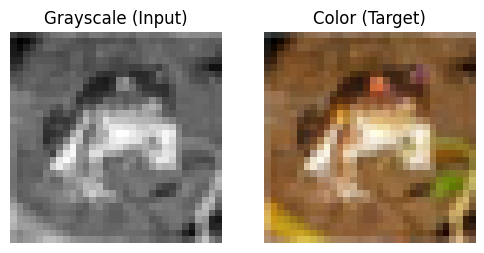

In [6]:
# Test your implementation
colorization_dataset = ColorizationDataset(cifar_data)

# Get a sample
gray_img, color_img = colorization_dataset[0]

print(f"Grayscale image shape: {gray_img.shape}")  # Should be (1, 32, 32)
print(f"Color image shape: {color_img.shape}")      # Should be (3, 32, 32)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(gray_img.squeeze(), cmap='gray')
axes[0].set_title('Grayscale (Input)')
axes[0].axis('off')
axes[1].imshow(color_img.permute(1, 2, 0))
axes[1].set_title('Color (Target)')
axes[1].axis('off')
plt.show()

In [7]:
# Test with DataLoader
dataloader = DataLoader(colorization_dataset, batch_size=8, shuffle=True)

gray_batch, color_batch = next(iter(dataloader))
print(f"Batch grayscale shape: {gray_batch.shape}")  # Should be (8, 1, 32, 32)
print(f"Batch color shape: {color_batch.shape}")      # Should be (8, 3, 32, 32)

Batch grayscale shape: torch.Size([8, 1, 32, 32])
Batch color shape: torch.Size([8, 3, 32, 32])
